## Xray Lung Classifier 

---
### Project flow  

1) Importing the libraries and Loading the Images

2) Exploring the Images and transforming the Images

3) Creating the model Architecture

4) Training the Data

5) Evaluate the Model 

---
### Importing the libraries and Loading the Images

In [1]:
!pip install wandb

     ---------------------------------------- 0.0/24.2 MB ? eta -:--:--
     --------------------------------------- 0.0/24.2 MB 330.3 kB/s eta 0:01:14
     --------------------------------------- 0.1/24.2 MB 787.7 kB/s eta 0:00:31
     ---------------------------------------- 0.2/24.2 MB 1.4 MB/s eta 0:00:18
      --------------------------------------- 0.4/24.2 MB 2.1 MB/s eta 0:00:12
      --------------------------------------- 0.6/24.2 MB 2.5 MB/s eta 0:00:10
     - -------------------------------------- 0.8/24.2 MB 2.9 MB/s eta 0:00:09
     - -------------------------------------- 1.0/24.2 MB 3.2 MB/s eta 0:00:08
     - -------------------------------------- 1.2/24.2 MB 3.2 MB/s eta 0:00:08
     -- ------------------------------------- 1.4/24.2 MB 3.5 MB/s eta 0:00:07
     -- ------------------------------------- 1.5/24.2 MB 3.3 MB/s eta 0:00:07
     -- ------------------------------------- 1.7/24.2 MB 3.5 MB/s eta 0:00:07
     --- ------------------------------------ 2.0/24.2 MB


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import matplotlib.image as mpimg
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm
import wandb


c:\Users\ASUS\OneDrive\Desktop\lung_disease_digonosis\.venv\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Initialize the wait and bais for expriment graphs
wandb.init(
    project='Lungs_Disease_Dygonosis',
    config={
        'epochs': 50,
        'batch_size': 16,
        'learning_rate': 0.001,
        'architecture': 'custom cnn',
        'pretrained': False,
        'input_size': 224
    }    
)

config = wandb.config


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ASUS\_netrc.
wandb: Currently logged in as: vk0099678 (vk0099678-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
# data path
data_path = 'C:\\Users\\ASUS\\OneDrive\\Desktop\\lung_disease_digonosis\\Data'

---
### Exploring the Images and transforming the Images

In [4]:
# Defining the class name 
class_name = ['NORMAL','PNEUMONIA']

# creating a function to get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    file_list = os.listdir(dir_name)
    return file_list

# passing the data_path and extract the train and test path
file_list_normal_train = get_list_of_files(data_path+'/train/'+class_name[0])
file_list_normal_test = get_list_of_files(data_path+'/test/'+class_name[0])
file_list_pneumonia_train = get_list_of_files(data_path+'/train/'+class_name[1])
file_list_pneumonia_test = get_list_of_files(data_path+'/test/'+class_name[1])

In [5]:
print(f"Number of train samples in Normal category {len(file_list_normal_train)}")
print(f"Number of train samples in Pneumonia category {len(file_list_pneumonia_train)}")
print(f"Number of test samples in Normal category {len(file_list_normal_test)}")
print(f"Number of test samples in Pneumonia category {len(file_list_pneumonia_test)}")

Number of train samples in Normal category 1266
Number of train samples in Pneumonia category 3418
Number of test samples in Normal category 317
Number of test samples in Pneumonia category 855


---
### Exploring the images 

- Let's print the Normal and Pneumonia images from Training folder 

(1125, 1324, 3)


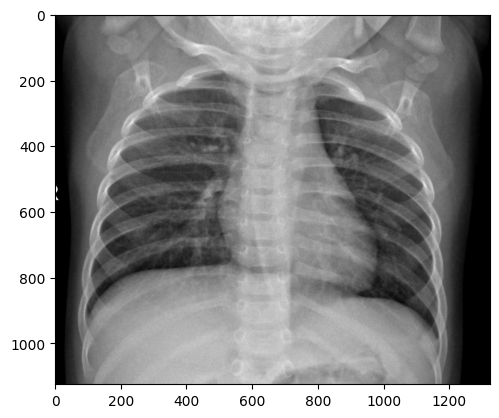

In [6]:
rand_img_no = np.random.randint(0, len(file_list_normal_train))
img = data_path+'/train/NORMAL/'+file_list_normal_train[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
img_plot = plt.imshow(img)
plt.show()

(696, 1024, 3)


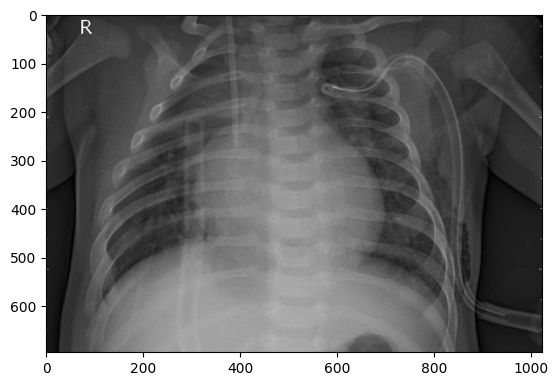

In [7]:
img = data_path + '/train/PNEUMONIA/'+ file_list_pneumonia_train[np.random.randint(0,len(file_list_pneumonia_train))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

### Insights 

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **train** folder.

(1104, 1240, 3)


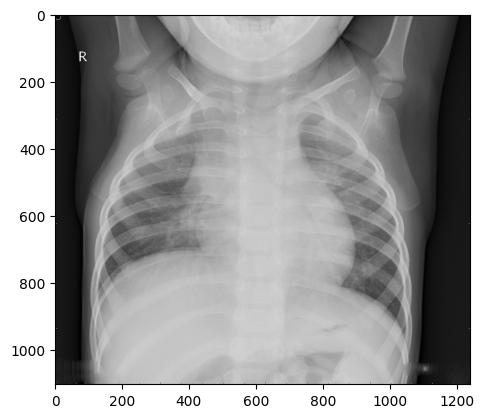

In [8]:
rand_img_no = np.random.randint(0,len(file_list_normal_test))
img = data_path + '/test/NORMAL/'+ file_list_normal_test[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(585, 985, 3)


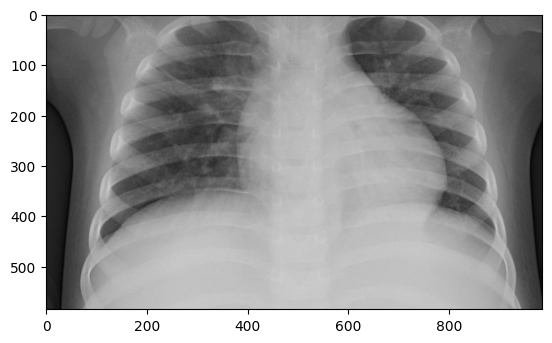

In [9]:
img = data_path + '/test/PNEUMONIA/'+ file_list_pneumonia_test[np.random.randint(0,len(file_list_pneumonia_test))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

### Insights 

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **test** folder.

### Transforming the Images 

- Now that we have seen the sample of the images let's transform the data now 
- We need to perform transformation on both train and test images 
- For Training data we need to perform the data augmentation also.
- Data Augmentation is done to create synthetic data.

In **Transformation** we are doing Resize,CenterCrop,ColorJitter,RandomHorizontalFlip,RandomRotation,ToTensor and Normalize.

- Resize:- Resize the input image to the given size.
- CenterCrop:- Crops the given image at the center.
- ColorJitter:- Randomly change the brightness, contrast, saturation and hue of an image.
- RandomHorizontalFlip:- Horizontally flip the given image randomly with a given probability.
- RandomRotation:- Rotate the image by angle.
- ToTensor:- Convert numpy.ndarray to tensor.
- Normalize:- Normalize a float tensor image with mean and standard deviation.

In [10]:
# Data Transformation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    # Data Agumentation
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(), # Randomly flips the image left-to-right.
    transforms.RandomRotation(10), # Randomly rotates the image.(between -10 to +10 degree)
    # preprocess
    transforms.ToTensor(), # convert it into pytorch tensor
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224), # CenterCrop crops the center portion of an image to a specified size.
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

### Creating Data Loader

- For our usecase will be using the default data loader for Pytorch.
- We will be creating 2 data loaders one for the training data and other for the test data.
- batch size is a hyperparameter which we can tweak according to our need and system configuration.
- We can provide Image shuffling True for training data and False for test data.
- Pin memory is used to transfer the loaded dataset from CPU to GPU. 

In [11]:
train_data = datasets.ImageFolder(
    os.path.join(data_path, 'train'),
    transform=train_transform
)

test_data = datasets.ImageFolder(
    os.path.join(data_path, 'test'),
    transform=test_transform
)

# data loader
train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_data,
    batch_size=16,
    shuffle=False,
    pin_memory=True
)

name_classes = train_data.classes
print(f"Class Name: {name_classes}")

print(f"Number of images in train data: {len(train_data)}")       
print(f"Number of images in test data: {len(test_data)}")

Class Name: ['NORMAL', 'PNEUMONIA']
Number of images in train data: 4684
Number of images in test data: 1172


---
### Creating the model Architecture

- First Layer is the **input layer** consisting of 3 input channels and output channels with kernel_size of 3X3, padding=0 and bias=True. The activation function we are using is ReLU and performing batch normalization.
- Then we are performing max pooling to extract the important features out of the image.
- Similarly we are passing our model through 9 convolutional layers.
- Finally we are passing out passing our model through a output layer in which we are getting binary classification.


In [12]:
# custom cnn
class Net(nn.Module):
    """
    Custom CNN Arcitecture for Image Classification

    """
    # Inherit and initialize the parent nn.Module class
    def __init__(self):
        super(Net, self).__init__()
        # Input Block
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=8,
                kernel_size=(3,3),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pooling1 = nn.MaxPool2d(2, 2)
        # Conv block 1
        self.conv_block11 = nn.Sequential(
            nn.Conv2d(
                in_channels=8,
                out_channels=20,
                kernel_size=(3, 3),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.pooling11 = nn.MaxPool2d(2, 2)

        self.conv_block12 = nn.Sequential(
            nn.Conv2d(
                in_channels=20,
                out_channels=10,
                kernel_size=(1, 1),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.pooling12 = nn.MaxPool2d(2, 2)
        # Conv block 2
        self.conv_block21 = nn.Sequential(
            nn.Conv2d(
                in_channels=10,
                out_channels=20,
                kernel_size=(3, 3),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )

        self.conv_block22 = nn.Sequential(
            nn.Conv2d(
                in_channels=20,
                out_channels=32,
                kernel_size=(1, 1),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(32)
        )

        self.conv_block23 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=10,
                kernel_size=(3, 3),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )

        self.conv_block24 = nn.Sequential(
            nn.Conv2d(
                in_channels=10,
                out_channels=10,
                kernel_size=(1, 1),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )

        self.conv_block25 = nn.Sequential(
            nn.Conv2d(
                in_channels=10,
                out_channels=14,
                kernel_size=(3, 3),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )

        self.conv_block26 = nn.Sequential(
            nn.Conv2d(
                in_channels=14,
                out_channels=16,
                kernel_size=(3, 3),
                padding=0,
                bias=True
            ),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # Output Block
        self.gap = nn.AdaptiveAvgPool2d(1)
        # classification layer
        self.classifier = nn.Conv2d(
            in_channels=16,
            out_channels=2,
            kernel_size=(1, 1)
        )

    # forward pass
    def forward(self, x):
        # input block
        x = self.conv_block1(x)
        x = self.pooling1(x)
        # conv block1
        x = self.conv_block11(x)
        x = self.pooling11(x)
        x = self.conv_block12(x)
        x = self.pooling12(x)
        # conv block2
        x = self.conv_block21(x)
        x = self.conv_block22(x)
        x = self.conv_block23(x)
        x = self.conv_block24(x)
        x = self.conv_block25(x)
        x = self.conv_block26(x)
        # average polling
        x = self.gap(x)
        # output layer having 2 neurons(2 class classification layer)
        x = self.classifier(x)
        # flatten the layer
        x = torch.flatten(x, 1)

        return x        


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Available Processor: {device}")

model = Net().to(device)
# watch the model's weights and gradients
wandb.watch(model, log="all", log_freq=10)

# model summary
summary(model, input_size=(3, 224, 224))

Available Processor: cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
       BatchNorm2d-3          [-1, 8, 222, 222]              16
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 20, 109, 109]           1,460
              ReLU-6         [-1, 20, 109, 109]               0
       BatchNorm2d-7         [-1, 20, 109, 109]              40
         MaxPool2d-8           [-1, 20, 54, 54]               0
            Conv2d-9           [-1, 10, 54, 54]             210
             ReLU-10           [-1, 10, 54, 54]               0
      BatchNorm2d-11           [-1, 10, 54, 54]              20
        MaxPool2d-12           [-1, 10, 27, 27]               0
           Conv2d-13           [-1, 20, 25, 25]           1,820
             R

In [16]:
# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.learning_rate
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [17]:
## Training loop
# Write a function to train the model(training loop)
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        running_loss = 0.0
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print('-' * 60)
        for batch_idx, (img, label) in enumerate(train_loader):
            img, label = img.to(device), label.to(device)
            optimizer.zero_grad() # update the classifier weights
            outputs = model(img)
            # cal loss
            loss = criterion(outputs, label)
            loss.backward() # backpropagation
            optimizer.step() # updates your model’s parameters using the gradients computed during backpropagation.

            # training loss
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            batch_correct = (preds == label).sum().item()
            train_correct += batch_correct
            train_total += label.size(0)

            # print every 10 batches
            if (batch_idx + 1) % 10 == 0:
                batch_acc = batch_correct / label.size(0)
                print(f"[Batch {batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}, Batch Accuracy: {batch_acc:.4f}")
        
        train_acc = train_correct / train_total
        train_loss = running_loss / len(train_loader)

        print(f'Epoch {epoch + 1} Summary - Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}')

        # validation loop
        model.eval() # make the model in evalutation mode
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for img, label in val_loader:
                img, label = img.to(device), label.to(device)

                outputs = model(img)
                loss = criterion(outputs, label)
                val_loss += loss.item()

                _, pred = torch.max(outputs, 1)
                val_correct += (pred == label).sum().item()
                val_total += label.size(0)

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)
        # Update learning rate based on validation loss
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Validation Accuracy: {val_acc:.4f} | "
            f"Validation Loss: {val_loss:.4f} | "
            f"Learning Rate: {current_lr:.6f}"
        )

        wandb.log({
            'epoch': epoch + 1,
            'train_accuracy': train_acc,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'learning_rate': current_lr
        })

        


In [18]:
# train the model
train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    train_loader,
    test_loader,
    epochs=config.epochs
)


Epoch 1/50
------------------------------------------------------------
[Batch 10/293] Loss: 0.5377, Batch Accuracy: 0.8125
[Batch 20/293] Loss: 0.5079, Batch Accuracy: 0.7500
[Batch 30/293] Loss: 0.2968, Batch Accuracy: 0.9375
[Batch 40/293] Loss: 0.6257, Batch Accuracy: 0.8125
[Batch 50/293] Loss: 0.1987, Batch Accuracy: 1.0000
[Batch 60/293] Loss: 0.3385, Batch Accuracy: 0.8750
[Batch 70/293] Loss: 0.5086, Batch Accuracy: 0.7500
[Batch 80/293] Loss: 0.8471, Batch Accuracy: 0.6875
[Batch 90/293] Loss: 0.5563, Batch Accuracy: 0.7500
[Batch 100/293] Loss: 0.4998, Batch Accuracy: 0.6875
[Batch 110/293] Loss: 0.3158, Batch Accuracy: 0.8750
[Batch 120/293] Loss: 0.3610, Batch Accuracy: 0.7500
[Batch 130/293] Loss: 0.1934, Batch Accuracy: 1.0000
[Batch 140/293] Loss: 0.2278, Batch Accuracy: 0.9375
[Batch 150/293] Loss: 0.2989, Batch Accuracy: 0.9375
[Batch 160/293] Loss: 0.3112, Batch Accuracy: 0.8750
[Batch 170/293] Loss: 0.2693, Batch Accuracy: 0.8750
[Batch 180/293] Loss: 0.3006, Batch

In [19]:
# Evaluate the model performance on test_loader
def evaluate_model(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Test Accuracy: {accuracy:.2f}%")

    return accuracy

In [20]:
evaluate_model(model, test_loader)

Test Accuracy: 95.90%


95.90443686006826

In [29]:
# preprocess
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_and_check(img_path, true_label=None):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    img_tensor = predict_transform(img)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)

        probs = torch.softmax(outputs, dim=1)

        confidence, pred = torch.max(probs, dim=1)

    pred_class = class_names[pred.item()]

    print(f"Predicted: {pred_class}")
    print(f"Confidence: {confidence.item()*100:.2f}%")

    if true_label is not None:
        if pred_class.lower() == true_label.lower():
            print("✓ Correct Prediction")
        else:
            print("✗ Wrong Prediction")

    plt.imshow(img)
    plt.title(f"{pred_class} ({confidence.item()*100:.2f}%)")
    plt.axis("off")
    plt.show()

In [30]:
# class names
class_names = train_data.classes
class_names

['NORMAL', 'PNEUMONIA']

Predicted: PNEUMONIA
Confidence: 99.83%
✓ Correct Prediction


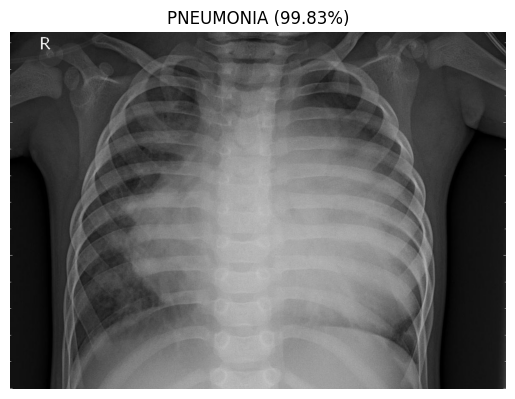

Predicted: NORMAL
Confidence: 64.67%
✓ Correct Prediction


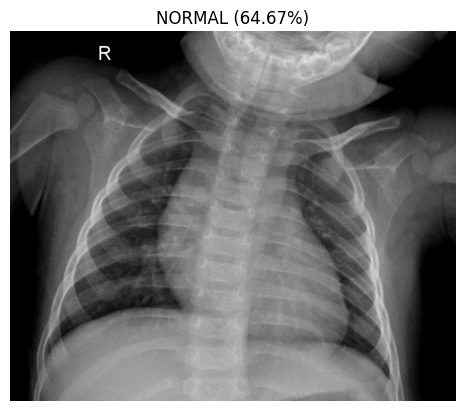

Predicted: NORMAL
Confidence: 99.72%
✓ Correct Prediction


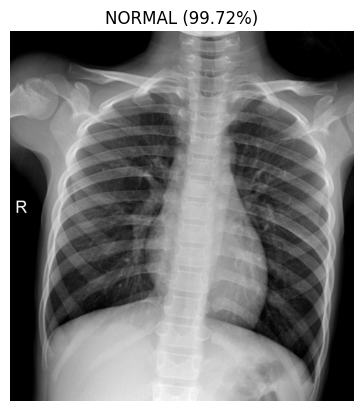

In [34]:
# image paths
img_paths = {
    'C:/Users/ASUS/OneDrive/Desktop/lung_disease_digonosis/Data/test/PNEUMONIA/PNEUMONIA(3420).jpg': 'PNEUMONIA',
    'C:/Users/ASUS/OneDrive/Desktop/lung_disease_digonosis/Data/test/NORMAL/NORMAL(1269).jpg': 'NORMAL',
    'C:/Users/ASUS/OneDrive/Desktop/lung_disease_digonosis/Data/test/NORMAL/NORMAL(1270).jpg': 'NORMAL'
}

for img, label in img_paths.items():
    predict_and_check(img, label)

# Here is the training and validation report using wandb
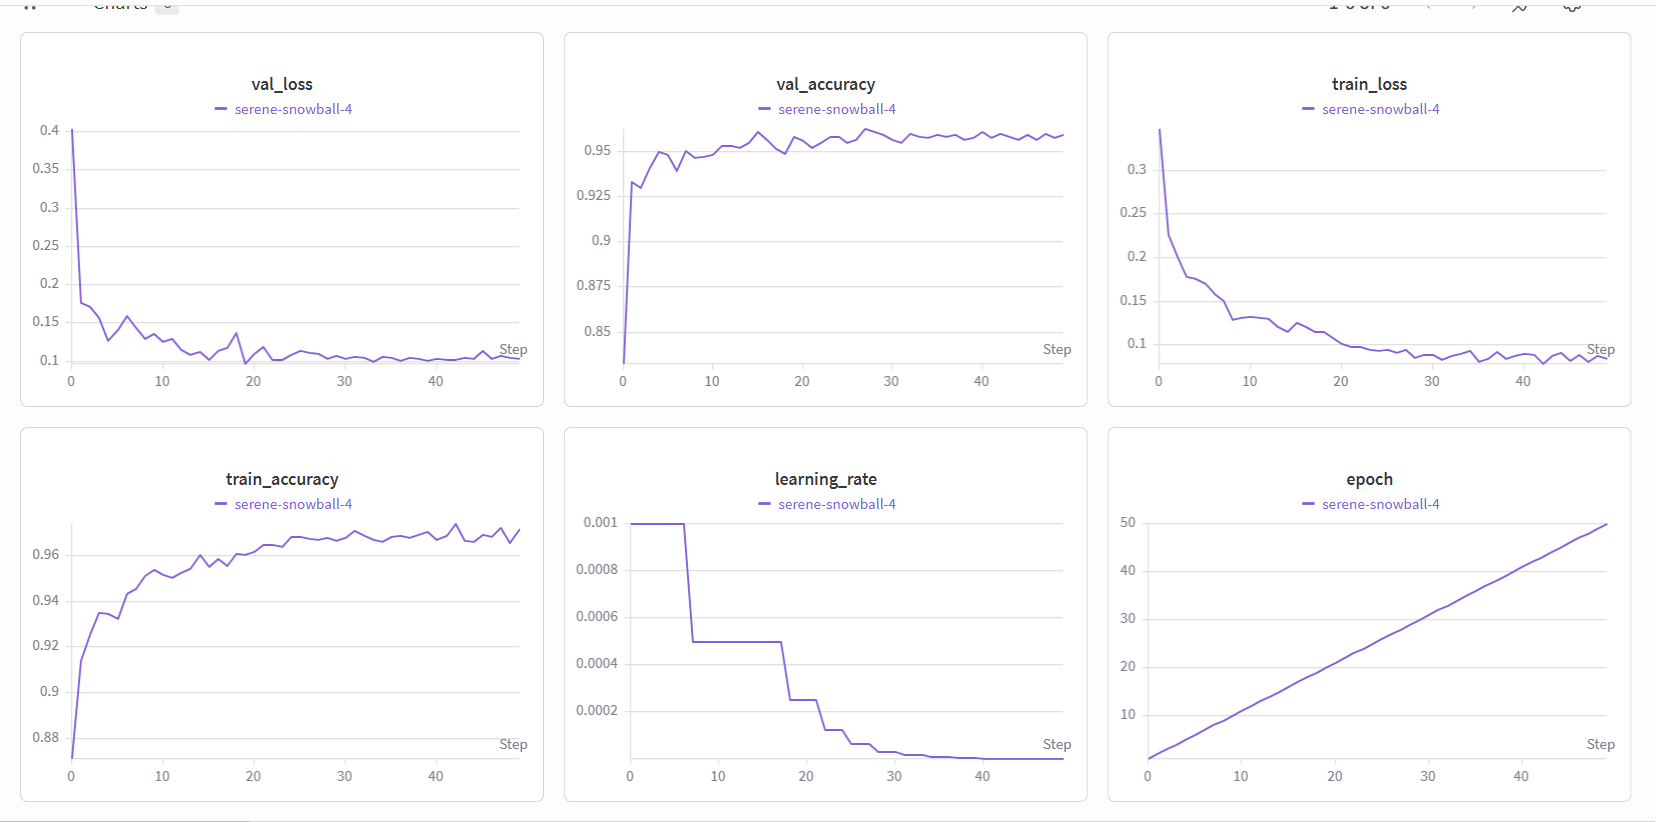

In [35]:
# save the model
torch.save(model.state_dict(), "xray_model.pth")